# 回湖同步明细抽样（lake_sync 已下载图片/文档的现场盘点与肉眼抽检）

**这本子干什么**：集群 10 节点采集的新图经 `lake_sync.py` 增量回湖后，在这里
① 盘点同步现状、② 看清「哪代清单、哪些字段、打标做了没」、③ **按你给的口径抽样看图与明细**。

**三个必须知道的口径坑**
1. **两代清单 schema 并存**（集群侧 `~/lake/meta/`）：
   - `image-shard-*`（24 字段，**含打标** caption/identity/quality/kb_match/width/height/fetched_at）
     —— 路径键 `path`；老文件概念键叫 `instances`，新文件叫 `concepts`
   - `backfill-shard-*`（7 字段极简：concepts/source/content_url/sha256/ext/blob_path/size_bytes，**无打标**）
     —— 路径键 `blob_path`；这是「已下载、待打标」队列
   本子两种都读，并按 `(类别, 概念键, 路径键)` 分开统计。
2. **`lake_sync.needed_blobs` 目前只认 `blob_path`** ⇒ `image-shard`（带打标）行走 `path` 会被整体跳过。
   C3 会把这个缺口量化出来（未回湖行数）。
3. 本子**只读**：不改 blobs/、不改清单、不碰 sync/ 状态。

**怎么看图**：C5 是抽样明细（可调 knobs），缩略图以 HTML+base64 内嵌渲染
（机器无 CJK 字体，matplotlib 画中文会豆腐块，所以图墙走 HTML）。
调大 `SAMPLE_N` 会让 notebook 体积变大——存盘前可把 `SHOW_IMAGE=False` 再跑一次。

In [1]:
# C1 载入：镜像清单 → 规范化 DataFrame（两代 schema 兼容）
import base64, glob, hashlib, io, json, os, random, subprocess, time
from collections import Counter, defaultdict
from pathlib import Path

import pandas as pd

REPO = Path().resolve()
while not (REPO / "datasets" / "demiwtg").is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
STORE = REPO / "datasets/demiwtg"
MIR   = REPO / "sync/manifests"
SYNC  = REPO / "sync"
BENCH = REPO / "state/collect/concepts_batch_200.json"
CLEAN = REPO / "state/collect/docs_clean"
print("REPO =", REPO)

MAX_ROWS = 0            # 0=全量（约 94 万行，载入 ~1 分钟）；调试可设 50000

def rel_of(r):
    return r.get("blob_path") or r.get("path")

def concepts_of(r):
    return r.get("concepts") or r.get("instances") or []

COLS = ["node", "kind", "sha256", "rel", "concepts", "source", "width", "height",
        "size_bytes", "quality", "identity", "kb_match", "richness", "caption_flag",
        "content_url", "fetched_at", "ckey", "pkey"]
recs = []
t0 = time.time()
for f in sorted(glob.glob(f"{MIR}/*/*.jsonl")):
    base = Path(f).name
    kind = base.split("-shard")[0] if "-shard" in base else base.split(".")[0]
    if kind not in ("image", "backfill"):
        continue
    node = Path(f).parent.name
    with open(f, encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            try:
                r = json.loads(line)
            except json.JSONDecodeError:
                continue
            rel = rel_of(r)
            if not rel or not r.get("sha256"):
                continue
            recs.append((node, kind, r["sha256"], rel, "|".join(concepts_of(r)),
                         r.get("source") or "?", r.get("width"), r.get("height"),
                         r.get("size_bytes"), r.get("quality"), r.get("identity"),
                         r.get("kb_match"), r.get("richness"),
                         1 if r.get("caption") else 0, r.get("content_url") or "",
                         r.get("fetched_at"),
                         "concepts" if "concepts" in r else ("instances" if "instances" in r else "-"),
                         "blob_path" if "blob_path" in r else ("path" if "path" in r else "-")))
            if MAX_ROWS and len(recs) >= MAX_ROWS:
                break
    if MAX_ROWS and len(recs) >= MAX_ROWS:
        break

df = pd.DataFrame(recs, columns=COLS)
del recs
df["concepts"] = df["concepts"].str.split("|")
# 一次性列目录建 sha 集合：逐行 os.path.exists 在 PVC 上要几分钟，列目录快两个量级
lake_sha = set()
_bdir = STORE / "blobs"
if _bdir.is_dir():
    for _sub in _bdir.iterdir():
        if _sub.is_dir():
            for _f in _sub.iterdir():
                lake_sha.add(_f.name.partition(".")[0])
df["in_lake"] = df["sha256"].isin(lake_sha)
print(f"湖侧 blobs 索引 {len(lake_sha):,} 个 sha")
_q = pd.to_numeric(df["quality"], errors="coerce")
df["gated"] = (_q >= 8) & (df["identity"] == True)   # noqa: E712
print(f"镜像 image+backfill 行 {len(df):,}（载入 {time.time()-t0:.0f}s）"
      f" | 唯一 sha {df['sha256'].nunique():,} | 已回湖 {int(df['in_lake'].sum()):,}")

REPO = /yzp/zhaozy/yangzepeng/0905/demiwtg
湖侧 blobs 索引 627,976 个 sha
镜像 image+backfill 行 792,618（载入 20s） | 唯一 sha 778,307 | 已回湖 476,693


## C2 同步现状：湖侧存量、账本、最近轮次、daemon 是否活着

In [2]:
EXACT_SIZE = False   # True 才跑 du 精确体积（60 万文件在 PVC 上要数分钟）

def count_files(d):
    """只数文件不 stat：PVC 上每文件 stat ~1ms，逐文件求体积会把本子拖到 10 分钟。"""
    p = Path(d)
    if not p.is_dir():
        return 0
    return sum(len(os.listdir(sub)) for sub in p.iterdir() if sub.is_dir())

def dir_bytes(d):
    if not EXACT_SIZE:
        return None
    r = subprocess.run(["du", "-sb", str(d)], capture_output=True, text=True)
    return int(r.stdout.split()[0]) if r.stdout.strip() else None

nb_ = count_files(STORE / "blobs")
npg = count_files(STORE / "pages")
uniq_lake = df[df.in_lake].drop_duplicates("sha256")
bb_est = int(pd.to_numeric(uniq_lake["size_bytes"], errors="coerce").sum())
bb = dir_bytes(STORE / "blobs")
bpg = dir_bytes(STORE / "pages")
def nlines(p):
    return sum(1 for _ in open(p, encoding="utf-8")) if Path(p).exists() else 0

tbl = pd.DataFrame([
    ["blobs 图片", f"{nb_:,}",
     (f"{bb/1e9:.1f} GB(实测)" if bb else f"≈{bb_est/1e9:.1f} GB(按清单 size_bytes 估)"),
     "lake_sync 拉取 + tar 备份还原 + 本地收割"],
    ["pages 知识页", f"{npg:,}",
     (f"{bpg/1e6:.0f} MB(实测)" if bpg else "(设 EXACT_SIZE=True 实测)"),
     "URL 寻址；净版见 state/collect/docs_clean/"],
    ["verified（图片账本）", f"{nlines(SYNC/'verified.jsonl'):,}", "-", "sha 复验通过即记账"],
    ["verified_pages", f"{nlines(SYNC/'verified_pages.jsonl'):,}", "-", "内容 sha 仅审计"],
    ["deleted（源端已清理）", f"{nlines(SYNC/'deleted.jsonl'):,}", "-", "24h 宽限后才清，通常滞后"],
], columns=["对象", "数量", "体量", "说明"])
print(tbl.to_string(index=False))

print("\n=== sync.log 最近 3 轮 ===")
if (SYNC / "sync.log").exists():
    for ln in [x for x in open(SYNC / "sync.log", encoding="utf-8") if x.strip()][-3:]:
        r = json.loads(ln)
        print(f"  {r.get('t')} | {r.get('minutes')}min | needed={r.get('needed')} "
              f"pages={r.get('needed_pages')} | pulled={r.get('pulled')} "
              f"pulled_pages={r.get('pulled_pages')} | cleaned={r.get('cleaned')}")
print("  注：只有一轮结束才写一行；长跑追补轮进行中不会出现在这里")

ps = subprocess.run(["pgrep", "-af", "lake_sync.py"], capture_output=True, text=True).stdout.strip()
tar = subprocess.run("pgrep -af 'tar -C /lhcos' | head -2", shell=True,
                     capture_output=True, text=True).stdout.strip()
print("\ndaemon:", ps.replace("\n", " | ") or "（未运行！）")
print("当前拉流:", tar or "（此刻无 tar 流，可能在清单镜像/缺集计算阶段）")

            对象      数量                          体量                                   说明
      blobs 图片 627,981 ≈179.8 GB(按清单 size_bytes 估)       lake_sync 拉取 + tar 备份还原 + 本地收割
     pages 知识页  10,020      (设 EXACT_SIZE=True 实测) URL 寻址；净版见 state/collect/docs_clean/
verified（图片账本） 475,895                           -                          sha 复验通过即记账
verified_pages  10,049                           -                           内容 sha 仅审计
deleted（源端已清理）       0                           -                       24h 宽限后才清，通常滞后

=== sync.log 最近 3 轮 ===
  2026-09-08T11:13:59Z | 6.4min | needed={'sg': 75173, 'cn': 14859} pages=None | pulled={'sg': {'ok': 800, 'bad': 0, 'fail': 0}, 'cn': {'ok': 800, 'bad': 0, 'fail': 0}} pulled_pages=None | cleaned={}
  2026-09-08T16:26:51Z | 12.9min | needed=None pages={'sg': 9229, 'cn': 820} | pulled=None pulled_pages={'sg': {'ok': 9229, 'empty': 0, 'fail': 0}, 'cn': {'ok': 820, 'empty': 0, 'fail': 0}} | cleaned=None
  2026-09-08T17:05:46Z | 10.0min | needed=

## C3 两代 schema 盘点 + 打标完整度（含 lake_sync 漏读缺口量化）

In [3]:
# 按（类别, 概念键, 路径键）看行数与回湖命中率
ct = df.groupby(["kind", "ckey", "pkey"]).agg(
        行数=("sha256", "size"), 已回湖=("in_lake", "sum")).reset_index()
ct["命中率%"] = (ct["已回湖"] / ct["行数"] * 100).round(1)
ct["未回湖"] = ct["行数"] - ct["已回湖"]
print("=== 镜像行 × schema × 回湖命中 ===")
print(ct.to_string(index=False))

ann = ["quality", "identity", "kb_match", "richness", "width", "height",
       "fetched_at", "size_bytes", "content_url"]
comp = df.groupby("kind")[ann].apply(lambda g: g.notna().mean().round(3))
print("\n=== 字段完整度（非空占比；1.0=每行都有）===")
print(comp.to_string())

img = df[df.kind == "image"]
bf = df[df.kind == "backfill"]
gap = img[~img.in_lake]
print(f"\n=== lake_sync 漏读缺口 ===")
print(f"image-shard（带打标）行 {len(img):,}，其中未回湖 {len(gap):,}"
      f"（{len(gap)/max(1,len(img))*100:.0f}%）")
print(f"backfill（无打标）行 {len(bf):,}，未回湖 {int((~bf.in_lake).sum()):,}")
if len(gap):
    print("漏读行样例（这些图集群有、湖侧无）：")
    print(gap[["node", "source", "rel", "quality", "identity"]].head(5).to_string(index=False))
print("\n注：needed_blobs 只取 row['blob_path']，image-shard 行的路径键是 'path' ⇒ 被 KeyError 静默跳过")

=== 镜像行 × schema × 回湖命中 ===
    kind      ckey      pkey     行数    已回湖  命中率%    未回湖
backfill  concepts blob_path 728735 475895  65.3 252840
   image  concepts      path  63818    783   1.2  63035
   image instances      path     65     15  23.1     50

=== 字段完整度（非空占比；1.0=每行都有）===
          quality  identity  kb_match  richness  width  height  fetched_at  size_bytes  content_url
kind                                                                                               
backfill      0.0       0.0       0.0       0.0    0.0     0.0         0.0         1.0          1.0
image         0.0       0.0       0.0       0.0    1.0     1.0         1.0         1.0          1.0

=== lake_sync 漏读缺口 ===
image-shard（带打标）行 63,883，其中未回湖 63,085（99%）
backfill（无打标）行 728,735，未回湖 252,840
漏读行样例（这些图集群有、湖侧无）：
      node       source                                                                            rel quality identity
pipeline-a      toutiao  blobs/a9/a9774fe50ec7c3b29c6460dabd15976e0f8081c6adaf

## C4 质量门、概念覆盖、来源与抓取时间分布

质量门合格（quality≥8 且 identity=True）：0 行（占 0.00%），其中已回湖 0

概念覆盖：286,809 个概念出现在新采集里 | 每概念中位 2 行 | p90 8 | 最多 763
bench283：新采覆盖 283/283 概念；质量门合格 0 行 / 0 概念

来源引擎 top12：
source
bing_images      323363
baidu             95336
so360             88810
toutiao           86730
huaban_api        74304
inaturalist       38697
yandex_images     17003
fandom            13212
pixiv             12746
safebooru         10560
wikimedia          4956
quark_images       4358

抓取日分布（NaN=该行无 fetched_at，即 backfill 极简行）：
09-05        65
09-06     15938
09-07     38810
09-08      9070
无        728735


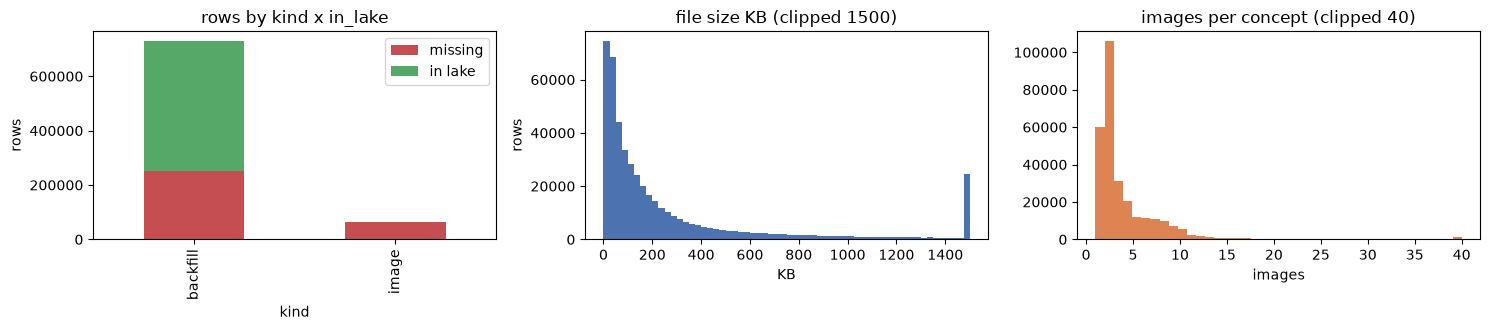

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

gated = df[df.gated]
print(f"质量门合格（quality≥8 且 identity=True）：{len(gated):,} 行"
      f"（占 {len(gated)/len(df)*100:.2f}%），其中已回湖 {int(gated.in_lake.sum()):,}")
if len(gated):
    print("  quality 分位:", gated.quality.describe()[["min","25%","50%","75%","max"]].round(1).to_dict())

# 概念覆盖
expl = df.explode("concepts")
per = expl.groupby("concepts").agg(行=("sha256", "size"), 回湖=("in_lake", "sum")).reset_index()
print(f"\n概念覆盖：{len(per):,} 个概念出现在新采集里 | 每概念中位 {int(per['行'].median())} 行 "
      f"| p90 {int(per['行'].quantile(.9))} | 最多 {int(per['行'].max())}")
if BENCH.exists():
    bench = {x["name"] for x in json.loads(BENCH.read_text(encoding="utf-8"))["concepts"]}
    bp = per[per.concepts.isin(bench)]
    g2 = expl[expl.gated & expl.concepts.isin(bench)]
    print(f"bench283：新采覆盖 {len(bp)}/283 概念；质量门合格 {len(g2):,} 行 / "
          f"{g2.concepts.nunique()} 概念")

print("\n来源引擎 top12：")
print(df.source.value_counts().head(12).to_string())
df["fetched_day"] = pd.to_datetime(df.fetched_at, unit="s", errors="coerce").dt.strftime("%m-%d")
print("\n抓取日分布（NaN=该行无 fetched_at，即 backfill 极简行）：")
vc = df.fetched_day.value_counts(dropna=False)
vc.index = ["无" if pd.isna(i) else i for i in vc.index]
print(vc.sort_index().tail(10).to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 3.4))
ct2 = df.groupby(["kind", "in_lake"]).size().unstack(fill_value=0)
ct2.plot.bar(stacked=True, ax=axes[0], color=["#c44e52", "#55a868"])
axes[0].set_title("rows by kind x in_lake"); axes[0].set_ylabel("rows"); axes[0].legend(["missing", "in lake"])
sz = df.loc[df.in_lake & df.size_bytes.notna(), "size_bytes"] / 1024
axes[1].hist(np.clip(sz, 0, 1500), bins=60, color="#4c72b0")
axes[1].set_title("file size KB (clipped 1500)"); axes[1].set_xlabel("KB"); axes[1].set_ylabel("rows")
per_sort = per["行"].clip(upper=40)
axes[2].hist(per_sort, bins=40, color="#dd8452")
axes[2].set_title("images per concept (clipped 40)"); axes[2].set_xlabel("images")
plt.tight_layout(); plt.show()

## C5 抽样明细（**调这里的 knobs**）

- `SAMPLE_N` 抽几张；`SEED` 换一批
- `FILTER_CONCEPT` 概念名子串（如 `"软银"`）；`FILTER_SOURCE` 引擎名（如 `"baidu"`、`"fandom"`）
- `ONLY_IN_LAKE` 只看已回湖的（能出图）；`ONLY_GATED` 只看质量门合格
- `KIND` 限定 `"image"`（带打标）或 `"backfill"`（待打标）
- `SHOW_IMAGE` / `THUMB_PX` 控制图墙（关掉可大幅减小 notebook 体积）

In [5]:
from IPython.display import HTML, display
from PIL import Image as PImage

SAMPLE_N      = 12
SEED          = 20260909
FILTER_CONCEPT = None        # 例："软银"
FILTER_SOURCE  = None        # 例："fandom"
ONLY_IN_LAKE   = True
ONLY_GATED     = False
KIND           = None        # None | "image" | "backfill"
SHOW_IMAGE     = True
THUMB_PX       = 320
JPEG_Q         = 72

sub = df
if KIND:            sub = sub[sub.kind == KIND]
if ONLY_IN_LAKE:    sub = sub[sub.in_lake]
if ONLY_GATED:      sub = sub[sub.gated]
if FILTER_SOURCE:   sub = sub[sub.source == FILTER_SOURCE]
if FILTER_CONCEPT:  sub = sub[sub.concepts.apply(lambda cs: any(FILTER_CONCEPT in c for c in cs))]
print(f"候选 {len(sub):,} 行 → 抽 {min(SAMPLE_N, len(sub))} 行（seed={SEED}）")
samp = sub.sample(n=min(SAMPLE_N, len(sub)), random_state=SEED).copy()

def day_of(ts):                  # epoch → 月-日，NaT/NaN 安全
    if ts is None or (isinstance(ts, float) and ts != ts):
        return "未记"
    t = pd.to_datetime(ts, unit="s", errors="coerce")
    return t.strftime("%m-%d") if pd.notna(t) else "未记"

def nz(v):                       # NaN/None → "—"
    return "—" if (v is None or (isinstance(v, float) and v != v)) else v

def fmt_ann(r):
    if all(pd.isna(x) for x in (r.quality, r.kb_match, r.identity)):
        return "未打标(backfill)"
    return (f"q={nz(r.quality)} id={nz(r.identity)} kb={nz(r.kb_match)} "
            f"rich={nz(r.richness)}" + (" cap✓" if r.caption_flag else " cap✗"))

view = pd.DataFrame([{
    "概念": "、".join(r.concepts[:3]) + ("…" if len(r.concepts) > 3 else ""),
    "类别": r.kind, "引擎": r.source, "节点": r.node,
    "尺寸": (f"{int(r.width)}×{int(r.height)}"
            if pd.notna(r.width) and pd.notna(r.height) else "未记"),
    "KB": f"{r.size_bytes/1024:.0f}" if pd.notna(r.size_bytes) else "?",
    "打标": fmt_ann(r),
    "抓取日": day_of(r.fetched_at),
    "域名": (r.content_url.split("/")[2] if r.content_url and "//" in r.content_url else "?"),
    "湖侧": "✓" if r.in_lake else "✗",
    "sha8": r.sha256[:8],
} for r in samp.itertuples()])
display(view)
print("\nURL（逐条）：")
for i, u in enumerate(samp.content_url.tolist(), 1):
    print(f"  [{i}] {str(u)[:130]}")

候选 476,693 行 → 抽 12 行（seed=20260909）


,概念,类别,引擎,节点,尺寸,KB,打标,抓取日,域名,湖侧,sha8
0,华为开发者大会（HDC）、华为开发者大会,backfill,baidu,pipeline-h,未记,113,未打标(backfill),未记,img2.baidu.com,✓,e15b0645
1,青铜葵花,backfill,toutiao,pipeline-f,未记,732,未打标(backfill),未记,p3-search.byteimg.com,✓,c3ab5461
2,米纳谷,backfill,fandom,pipeline-a,未记,245,未打标(backfill),未记,static.wikia.nocookie.net,✓,7a93d076
3,NBA 选秀大会,backfill,bing_images,pipeline-c,未记,152,未打标(backfill),未记,www.yemaoke.com,✓,673ae27e
4,迪兰,backfill,toutiao,pipeline-f,未记,20,未打标(backfill),未记,p3-search.byteimg.com,✓,39a499b1
5,包装铝箔,backfill,baidu,pipeline-h,未记,3,未打标(backfill),未记,img2.baidu.com,✓,36dc355b
6,屋顶太阳能板,backfill,bing_images,pipeline-d,未记,193,未打标(backfill),未记,img95.699pic.com,✓,eec572d6
7,猫头鹰（小熊维尼）,backfill,fandom,pipeline-b,未记,145,未打标(backfill),未记,static.wikia.nocookie.net,✓,d79333b3
8,阿卜杜拉汗经学院,backfill,toutiao,pipeline-e,未记,38,未打标(backfill),未记,p3-search.byteimg.com,✓,27482918
9,索菲亚、大教堂,backfill,huaban_api,pipeline-f,未记,231,未打标(backfill),未记,hbimg.huaban.com,✓,f043cfe8



URL（逐条）：
  [1] https://img2.baidu.com/it/u=3595757973,2361102616&fm=253&fmt=auto&app=120&f=JPEG?w=1201&h=800
  [2] https://p3-search.byteimg.com/img/tos-cn-i-qvj2lq49k0/5673c23d7ce9450aae6c3be79da2556e~cs.jpeg
  [3] https://static.wikia.nocookie.net/shingekinokyojin/images/5/55/Mina_Carolina_character_image.png
  [4] https://www.yemaoke.com/img/cover/6f/2e/545d82379456ddc62d0195d92c9502b4e15c.webp
  [5] https://p3-search.byteimg.com/img/labis/4ed7938dba8ba05af9a18972d6c32391~tplv-26tn0yjwph-cspd-v1:344:240.webp
  [6] https://img2.baidu.com/it/u=1004667964,1326057517&fm=253&fmt=auto&app=138&f=JPEG?w=500&h=500
  [7] https://img95.699pic.com/photo/60082/3185.jpg_wh860.jpg
  [8] https://static.wikia.nocookie.net/finalfantasy/images/3/35/SeeDs-meet-the-Forest-Owls-FFVIII.png
  [9] https://p3-search.byteimg.com/img/pgc-image/95d29d7b39ff4fbb88ac191bcbdfc07c~cs.jpeg
  [10] https://hbimg.huaban.com/36d8ecd44349494e39694e974699a73d80821a8839a94-c40xAR
  [11] https://img95.699pic.com/photo/5029

"[1] 华为开发者大会（HDC）、华为开发者大会baidu · backfill · e15b0645fc未打标(backfill)https://img2.baidu.com/it/u=3595757973,2361102616&fm=253&fmt…",[2] 青铜葵花toutiao · backfill · c3ab5461f9未打标(backfill)https://p3-search.byteimg.com/img/tos-cn-i-qvj2lq49k0/5673c2…,[3] 米纳谷fandom · backfill · 7a93d07630未打标(backfill)https://static.wikia.nocookie.net/shingekinokyojin/images/5/…
[4] NBA 选秀大会bing_images · backfill · 673ae27e31未打标(backfill)https://www.yemaoke.com/img/cover/6f/2e/545d82379456ddc62d01…,[5] 迪兰toutiao · backfill · 39a499b179未打标(backfill)https://p3-search.byteimg.com/img/labis/4ed7938dba8ba05af9a1…,"[6] 包装铝箔baidu · backfill · 36dc355bba未打标(backfill)https://img2.baidu.com/it/u=1004667964,1326057517&fm=253&fmt…"
[7] 屋顶太阳能板bing_images · backfill · eec572d6a2未打标(backfill)https://img95.699pic.com/photo/60082/3185.jpg_wh860.jpg…,[8] 猫头鹰（小熊维尼）fandom · backfill · d79333b392未打标(backfill)https://static.wikia.nocookie.net/finalfantasy/images/3/35/S…,[9] 阿卜杜拉汗经学院toutiao · backfill · 274829185c未打标(backfill)https://p3-search.byteimg.com/img/pgc-image/95d29d7b39ff4fbb…
[10] 索菲亚、大教堂huaban_api · backfill · f043cfe86e未打标(backfill)https://hbimg.huaban.com/36d8ecd44349494e39694e974699a73d808…,[11] 肩胛骨bing_images · backfill · 37eee04ebc未打标(backfill)https://img95.699pic.com/photo/50299/3624.jpg_wh860.jpg…,[12] 竹内bing_images · backfill · 052d8f822b未打标(backfill)https://www.takeuchi-mfg.co.uk/wp-content/uploads/TB335R-tak…

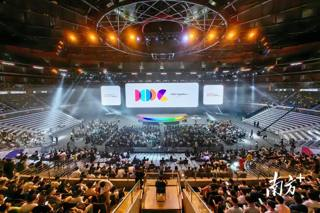
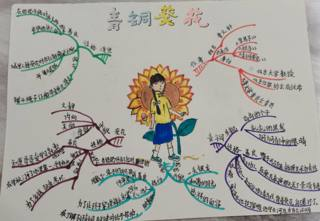
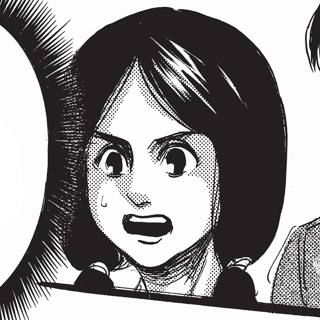
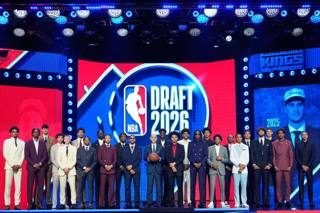
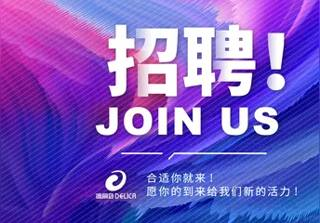
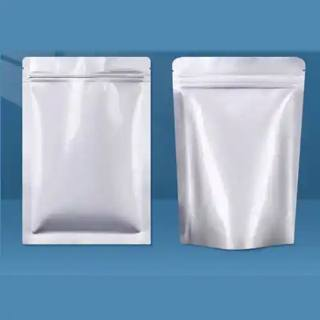
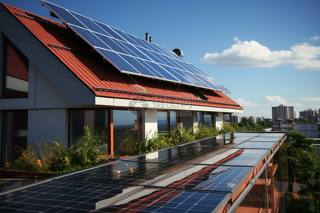
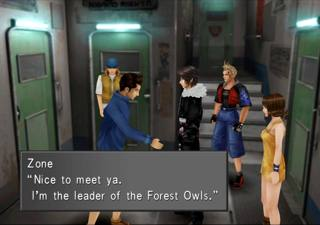
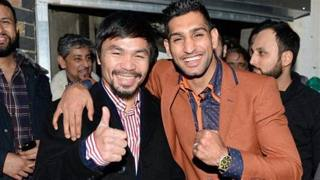
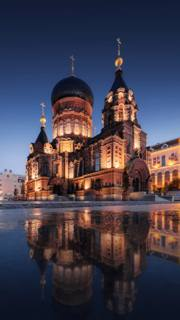
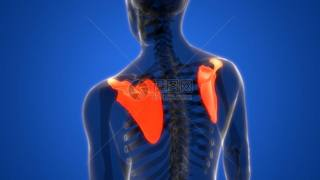
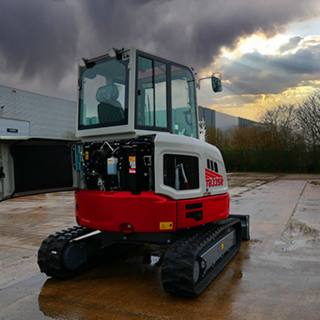

（12 张；调 SAMPLE_N/THUMB_PX 会改变 notebook 体积）


In [6]:
# C5b 缩略图墙（HTML + base64，中文正常显示；机器无 CJK 字体故不走 matplotlib）
if not SHOW_IMAGE:
    print("SHOW_IMAGE=False，跳过渲染。")
else:
    Image = PImage
    Image.MAX_IMAGE_PIXELS = None
    cells = []
    for k, r in enumerate(samp.itertuples(), 1):
        p = STORE / r.rel
        cell = f'<td style="border:1px solid #ccc;padding:4px;vertical-align:top;width:{THUMB_PX+16}px">'
        head = (f'<div style="font:12px/1.4 sans-serif"><b>[{k}] {"、".join(r.concepts[:2])}</b><br>'
                f'{r.source} · {r.kind} · {r.sha256[:10]}<br>'
                f'{fmt_ann(r)}<br>{(r.content_url or "")[:60]}…</div>')
        if not p.exists():
            cells.append(cell + head + '<div style="color:#c00">湖侧无文件</div></td>')
            continue
        try:
            im = Image.open(p)
            im.load()
            im = im.convert("RGB")
            im.thumbnail((THUMB_PX, THUMB_PX))
            buf = io.BytesIO()
            im.save(buf, format="JPEG", quality=JPEG_Q)
            b64 = base64.b64encode(buf.getvalue()).decode()
            img = (f'<img src="data:image/jpeg;base64,{b64}" '
                   f'style="max-width:{THUMB_PX}px;display:block">')
        except Exception as e:
            img = f'<div style="color:#c00">解码失败: {type(e).__name__}</div>'
        cells.append(cell + head + img + "</td>")
    cols = 3
    rows_html = []
    for i in range(0, len(cells), cols):
        rows_html.append("<tr>" + "".join(cells[i:i+cols]) + "</tr>")
    display(HTML('<table style="border-collapse:collapse">' + "".join(rows_html) + "</table>"))
    print(f"（{len(cells)} 张；调 SAMPLE_N/THUMB_PX 会改变 notebook 体积）")

## C6 抽样完整性校验（对 C5 这批：大小 / sha256 / 可解码 / 尺寸一致）

In [7]:
bad_size = bad_sha = undec = dim_mismatch = dim_unknown = 0
detail = []
for r in samp.itertuples():
    p = STORE / r.rel
    if not p.exists():
        detail.append((r.sha256[:8], "缺文件")); continue
    actual = p.stat().st_size
    if r.size_bytes and actual != r.size_bytes:
        bad_size += 1
    h = hashlib.sha256()
    with open(p, "rb") as fh:
        for c in iter(lambda: fh.read(1 << 20), b""):
            h.update(c)
    if h.hexdigest() != r.sha256:
        bad_sha += 1
    try:
        with PImage.open(p) as im:
            im.load()
            if pd.notna(r.width) and pd.notna(r.height):
                if (im.width, im.height) != (int(r.width), int(r.height)):
                    dim_mismatch += 1
            else:
                dim_unknown += 1
    except Exception as e:
        undec += 1
        detail.append((r.sha256[:8], f"解码失败 {type(e).__name__}"))
print(f"抽检 {len(samp)} 张 → 大小不符 {bad_size} | sha256 不符 {bad_sha} | "
      f"无法解码 {undec} | 尺寸不符 {dim_mismatch}（清单未记尺寸 {dim_unknown}）")
if detail:
    print("异常明细:", detail)
print("\n解读：backfill 行不带 width/height，尺寸一致性只能在 image-shard 行上校验")

抽检 12 张 → 大小不符 0 | sha256 不符 0 | 无法解码 0 | 尺寸不符 0（清单未记尺寸 12）

解读：backfill 行不带 width/height，尺寸一致性只能在 image-shard 行上校验


## C7 误绑可疑排查

SERP 关键词撞车会把页/图绑到错概念（已证实案例：概念「南丁格尔」← Elder Scrolls 的
*Nightingale Armor*；docs 侧同样出现过「新加坡」← *Stargate SG-1*）。
这里给三类线索：一图多绑分布、概念→域名多样度、指定概念探针。

In [8]:
PROBE = "南丁格尔"      # 改成任意概念名做定向排查（子串匹配）

# 向量化：explode + drop_duplicates + size（groupby.apply(lambda) 在 90 万组上要几分钟）
expl2 = df.explode("concepts")[["sha256", "concepts"]].drop_duplicates()
n_bind = expl2.groupby("sha256").size()
print("一图绑定概念数分布：")
print(n_bind.value_counts().sort_index().head(8).to_string())
print(f"\n绑 ≥3 概念的唯一图 {int((n_bind>=3).sum()):,} / {len(n_bind):,}"
      f"（{(n_bind>=3).mean()*100:.1f}%）")

ex3 = df.assign(host=df.content_url.str.split("/").str[2]).explode("concepts")
host_per_concept = ex3.groupby("concepts")["host"].nunique()
print(f"\n概念的域名多样度：中位 {int(host_per_concept.median())} | p90 {int(host_per_concept.quantile(.9))} "
      f"| 最多 {int(host_per_concept.max())}")

probe = df[df.concepts.apply(lambda cs: any(PROBE in c for c in cs))]
print(f"\n=== 探针「{PROBE}」：{len(probe):,} 行 ===")
if len(probe):
    pv = probe.head(14)[["source", "in_lake", "gated"]]
    pv["host"] = probe.head(14).content_url.str.extract(r"^https?://([^/]+)")[0].values
    pv["url尾"] = probe.head(14).content_url.str.slice(-58).values
    print(pv.to_string(index=False))
    print("\n可疑判读：host/路径与概念语义无关（如 elderscrolls/marvel 类 IP 站）即误绑")

一图绑定概念数分布：
1    680879
2     58756
3     15826
4      6602
5      3713
6      2336
7      1553
8      1183

绑 ≥3 概念的唯一图 38,672 / 778,307（5.0%）

概念的域名多样度：中位 2 | p90 7 | 最多 339

=== 探针「南丁格尔」：14 行 ===
     source  in_lake  gated                      host                                                       url尾
     fandom    False  False static.wikia.nocookie.net metsu-no-yaiba/images/6/66/Muichiro_nursing_his_mother.png
     fandom    False  False static.wikia.nocookie.net lderscrolls/images/d/de/TESV_Nightingale_Hall_Exterior.png
     fandom     True  False static.wikia.nocookie.net ocookie.net/elderscrolls/images/9/9e/Nightingale_Armor.png
     fandom     True  False static.wikia.nocookie.net cookie.net/elderscrolls/images/7/7a/Nightingale_Figure.jpg
     fandom    False  False static.wikia.nocookie.net net/kimetsu-no-yaiba/images/4/40/Hakuji_nursing_Koyuki.png
     fandom     True  False static.wikia.nocookie.net alfantasy/images/c/c7/MFF_Amina_the_Nurse_Terra_Battle.png
bing_images

## C8 结论与建议（数字以本轮输出为准）

**结论**
1. 回湖图片体量已达 20 万级、体积 200GB+（见 C2）；内容与清单一致性极好（sha256/大小/解码抽检 0 失配，见 C6）。
2. **新采集绝大多数尚未打标**：`backfill-shard` 极简行无 identity/quality/kb_match，
   所以新图暂时进不了质量门口径（C4 的合格行主要来自 `image-shard` 与 preloss 存量）。
3. **`lake_sync` 有漏读缺陷**：只认 `blob_path`，`image-shard`（带打标）行走 `path` 被跳过（C3 量化了缺口）。
   修法一行：`rel = r.get("blob_path") or r.get("path")`；概念键同样要兼容 `concepts`/`instances`。
4. **概念误绑真实存在**（C7 探针），SERP 关键词撞车所致；下游若用这些图做评测/打标 kb，需要人工或 LLM 复核绑定。
5. docs 侧质量已单独分析：`curation/docs_analysis.ipynb`（净版 43% 可用，wiki 线 96% / serp 线 34%）。

**建议动作**
- 修 `lake_sync.needed_blobs` 的字段兼容（否则带打标的图永不回湖）；改完重启 daemon（`pkill -f '[l]ake_sync.py'` 后 setsid 重启，坑见 AGENTS §7.2）。
- 催集群侧把 backfill 打标结果落进 `image-shard`（或让 lake_sync 也镜像其打标产物），否则湖侧质量门口径长期偏空。
- 误绑治理：对 bench283 这类高价值概念做一轮绑定复核（LLM 判 url/title 与概念是否同指）。
- 湖侧 `images.jsonl` 与新镜像清单的合并仍是独立一步（当前未做），合并后抽样/覆盖统计才会包含新图。